In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

In [2]:
x1, x2 = sp.symbols('x1 x2')
f = 5*x1**2 + x2**2 + 4*x1*x2 - 14*x1 - 6*x2 + 20
df_x1 = sp.diff(f, x1)
df_x2 = sp.diff(f, x2)
grad_fn = sp.lambdify((x1, x2), (df_x1, df_x2), 'numpy')
f_fn    = sp.lambdify((x1, x2), f, 'numpy')

def grad_f(x):
    return np.array(grad_fn(x[0], x[1]))

def f_val(x):
    return f_fn(x[0], x[1])

In [3]:

def exact_line_search(x, d):
    alpha = sp.Symbol('alpha')
    x1_new = x[0] + alpha * d[0]
    x2_new = x[1] + alpha * d[1]
    f_alpha = f.subs([(x1, x1_new), (x2, x2_new)])
    df_alpha = sp.diff(f_alpha, alpha)
    alpha_opt = sp.solve(df_alpha, alpha)[0]
    return float(alpha_opt)

iteration = 10000
x = np.zeros((iteration + 1, 2))
x[0] = np.array([0, 10])

for i in range(iteration):
    g = grad_f(x[i])
    d = -g  

    alpha_opt = exact_line_search(x[i], d)

    x[i+1] = x[i] + alpha_opt * d

    tolerance = abs(f_val(x[i]) - f_val(x[i+1]))
    print(f"{i+1}, x1={x[i][0]:.6f}, x2={x[i][1]:.6f}, d1 ={d[0]:.6f} d2={d[1]:.6f}  alpha={alpha_opt:.6f}, f={f_val(x[i]):.6f}")

    if tolerance <= 1e-12:
        print(f"\nConverged at iteration {i+1}: x1={x[i+1][0]:.4f}, x2={x[i+1][1]:.4f}")
        break
print("Optimal Value:", f_val(x[i+1]))

1, x1=0.000000, x2=10.000000, d1 =-26.000000 d2=-14.000000  alpha=0.086645, f=60.000000
2, x1=-2.252782, x2=8.786963, d1 =1.379968 d2=-2.562798  alpha=2.180000, f=22.222576
3, x1=0.755548, x2=3.200064, d1 =-6.355739 d2=-3.422321  alpha=0.086645, f=12.987827
4, x1=0.204852, x2=2.903535, d1 =0.337335 d2=-0.626480  alpha=2.180000, f=10.730379
5, x1=0.940243, x2=1.537809, d1 =-1.553670 d2=-0.836592  alpha=0.086645, f=10.178542
6, x1=0.805625, x2=1.465322, d1 =0.082462 d2=-0.153144  alpha=2.180000, f=10.043645
7, x1=0.985392, x2=1.131468, d1 =-0.379797 d2=-0.204506  alpha=0.086645, f=10.010669
8, x1=0.952485, x2=1.113749, d1 =0.020158 d2=-0.037436  alpha=2.180000, f=10.002608
9, x1=0.996429, x2=1.032138, d1 =-0.092842 d2=-0.049992  alpha=0.086645, f=10.000638
10, x1=0.988385, x2=1.027806, d1 =0.004928 d2=-0.009151  alpha=2.180000, f=10.000156
11, x1=0.999127, x2=1.007856, d1 =-0.022695 d2=-0.012221  alpha=0.086645, f=10.000038
12, x1=0.997161, x2=1.006797, d1 =0.001205 d2=-0.002237  alpha=2

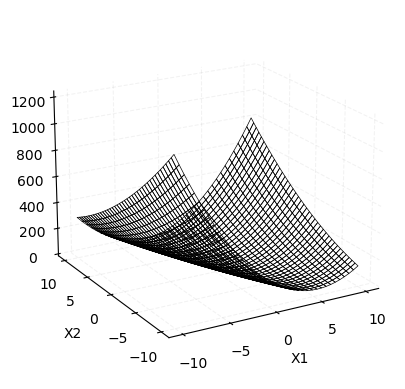

In [4]:
x1 = np.linspace(-10, 10, 40)
x2 = np.linspace(-10, 10, 40)
X1, X2 = np.meshgrid(x1, x2)
obj = f_fn(X1,X2)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X1, X2, obj, edgecolor='Black', linewidths=0.5,alpha=0)
ax.view_init(elev=20, azim=60)
ax.invert_xaxis()   
ax.invert_yaxis()   
ax.set_xlabel("X1")
ax.set_ylabel("X2")
ax.set_zlabel("f", labelpad=15)
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor('none')
ax.yaxis.pane.set_edgecolor('none')
ax.zaxis.pane.set_edgecolor('none')

ax.xaxis._axinfo["grid"]["linestyle"] = "--"
ax.yaxis._axinfo["grid"]["linestyle"] = "--"
ax.zaxis._axinfo["grid"]["linestyle"] = "--"
ax.xaxis._axinfo["grid"]["color"] = (0, 0, 0, 0.05)
ax.yaxis._axinfo["grid"]["color"] = (0, 0, 0, 0.05)
ax.zaxis._axinfo["grid"]["color"] = (0, 0, 0, 0.05)

plt.show()

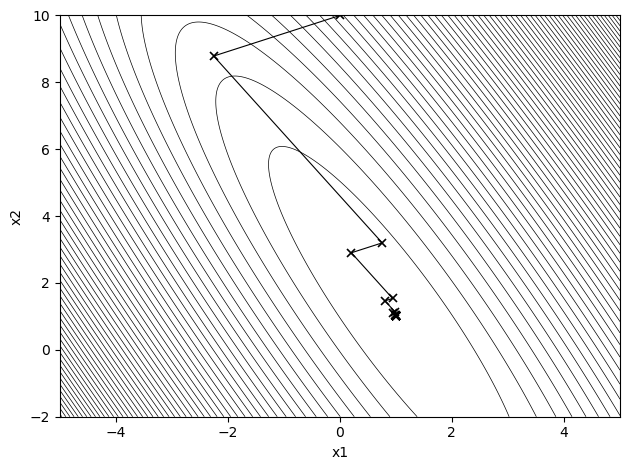

In [5]:
x1_range = np.linspace(-5, 5, 400)
x2_range = np.linspace(-2, 10, 400)
X1g, X2g = np.meshgrid(x1_range, x2_range)
Zg = f_fn(X1g, X2g)

path_x1 = x[:i+2, 0]
path_x2 = x[:i+2, 1]

fig, ax = plt.subplots()

levels = np.linspace(Zg.min(), Zg.max(), 60)
ax.contour(X1g, X2g, Zg, levels=levels, colors='black', linewidths=0.5)

ax.plot(path_x1, path_x2, 'k-', linewidth=0.8)
ax.plot(path_x1, path_x2, 'kx', markersize=6, markeredgewidth=1.2)

ax.set_xlim(-5, 5)
ax.set_ylim(-2, 10)
ax.set_xlabel('x1')
ax.set_ylabel('x2')
plt.tight_layout()
plt.show()

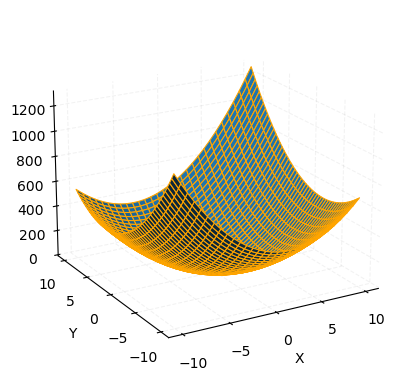

In [6]:
x1 = np.linspace(-10, 10, 30)
x2 = np.linspace(-10, 10, 50)
X1, X2 = np.meshgrid(x1, x2)
obj = 5*X1**2+4*X2**2 + 3*X1 * X2 + 7*X1 +20

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X1, X2, obj, edgecolor='orange', alpha=1,linewidth=0.8)
ax.view_init(elev=20, azim=60)
ax.invert_xaxis()   
ax.invert_yaxis()   
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("f", labelpad=15)
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor('none')
ax.yaxis.pane.set_edgecolor('none')
ax.zaxis.pane.set_edgecolor('none')

ax.xaxis._axinfo["grid"]["linestyle"] = "--"
ax.yaxis._axinfo["grid"]["linestyle"] = "--"
ax.zaxis._axinfo["grid"]["linestyle"] = "--"
ax.xaxis._axinfo["grid"]["color"] = (0, 0, 0, 0.05)
ax.yaxis._axinfo["grid"]["color"] = (0, 0, 0, 0.05)
ax.zaxis._axinfo["grid"]["color"] = (0, 0, 0, 0.05)
plt.show()

In [12]:
import numpy as np

def steepest_descent(Q, C, x0, tol=1e-6, max_iter=10000):
    x = x0.astype(float).copy()
    history = []

    for i in range(max_iter):
        grad = Q @ x - C          
        gnorm = np.linalg.norm(grad)

        if gnorm <= tol:
            break

        d = -grad

        denom = grad @ (Q @ grad)
        if denom <= 0:

            alpha = 0.0
        else:
            alpha = (grad @ grad) / denom

        x_new = x + alpha * d

        f_old = 0.5 * x @ Q @ x - C @ x + 10.0
        f_new = 0.5 * x_new @ Q @ x_new - C @ x_new + 10.0

        grad_new = Q @ x_new - C
        gnorm_new = np.linalg.norm(grad_new)

        history.append({
            'iter': i + 1,
            'x1':   x_new[0],
            'x2':   x_new[1],
            'f':    f_new,
            'alpha':alpha,
            '||g||':gnorm_new
        })

        x = x_new

    return history

def print_table(history, label):
    print(f"\n{'='*75}")
    print(f"  {label}")
    print(f"{'='*75}")
    print(f"{'Iter':>6} {'x1':>12} {'x2':>12} {'f(x)':>14} {'alpha':>12} {'||grad||':>12}")
    print(f"{'-'*75}")

    rows = history
    first10 = rows[:10]
    last10  = rows[-10:]

    for r in first10:
        print(f"{r['iter']:>6} {r['x1']:>12.6f} {r['x2']:>12.6f} {r['f']:>14.6f} {r['alpha']:>12.8f} {r['||g||']:>12.6f}")

    if len(rows) > 20:
        print(f"{'':>6}  {'...':^60}")

    for r in last10:
        if r not in first10:
            print(f"{r['iter']:>6} {r['x1']:>12.6f} {r['x2']:>12.6f} {r['f']:>14.6f} {r['alpha']:>12.8f} {r['||g||']:>12.6f}")

    print(f"{'-'*75}")
    print(f"  Converged at iteration {len(rows)} → x1={rows[-1]['x1']:.6f}, x2={rows[-1]['x2']:.6f}, f={rows[-1]['f']:.6f}")

# ── Case 1 ────────────────────────────────────────────────────────────────────
Q1 = np.array([[20, 5],
               [ 5, 2]])
C1 = np.array([14, 6])
x0 = np.array([40, -100])

h1 = steepest_descent(Q1, C1, x0)
print_table(h1, "Case 1: Q=[[20,5],[5,2]], C=[14,6], x0=[40,-100]")

# ── Case 2 ────────────────────────────────────────────────────────────────────
Q2 = np.array([[20,  5],
               [ 5, 16]])
C2 = np.array([14, 6])

h2 = steepest_descent(Q2, C2, x0)
print_table(h2, "Case 2: Q=[[20,5],[5,16]], C=[14,6], x0=[40,-100]")


  Case 1: Q=[[20,5],[5,2]], C=[14,6], x0=[40,-100]
  Iter           x1           x2           f(x)        alpha     ||grad||
---------------------------------------------------------------------------
     1    25.542693   -99.696700    3981.695128   0.05055003    77.697029
     2    26.277558   -64.668130    2620.587793   0.45093458   188.251915
     3    16.763512   -64.468535    1724.872077   0.05055003    51.130758
     4    17.247111   -41.416980    1135.420663   0.45093458   123.884571
     5    10.986120   -41.285630     747.515255   0.05055003    33.648062
     6    11.304366   -26.115894     492.242977   0.45093458    81.525795
     7     7.184142   -26.029455     324.253734   0.05055003    22.143072
     8     7.393573   -16.046575     213.703595   0.45093458    53.650387
     9     4.682141   -15.989692     140.952906   0.05055003    14.571884
    10     4.819963    -9.420171      93.077229   0.45093458    35.306176
                                    ...                   